In [1]:
import pandas as pd
import pickle
import matplotlib

from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader

C:\Users\Abarna Studio\AppData\Local\Temp\ipykernel_22412\404249496.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


## Dataset Paths

In [2]:
FAQ_PATH = "../data/customer_faq_500.csv"
PDF_PATH = "../data/company_policies.pdf"

In [3]:
faq_df = pd.read_csv(FAQ_PATH)
print("FAQ Dataset Loaded Successfully")
faq_df.head()

FAQ Dataset Loaded Successfully


,question,answer,category
0,Can I track multiple orders?,"Yes, each order has its own tracking informati...",Order Tracking
1,Why hasn't my order shipped?,Orders are usually processed within 24 hours. ...,Order Tracking
2,Where is my order?,You can track your order from the 'My Orders' ...,Order Tracking
3,Can I track multiple orders?,"Yes, each order has its own tracking informati...",Order Tracking
4,Why hasn't my order shipped?,Orders are usually processed within 24 hours. ...,Order Tracking


In [4]:
print("Dataset Shape:", faq_df.shape)
print()
faq_df.info()

Dataset Shape: (500, 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  500 non-null    object
 1   answer    500 non-null    object
 2   category  500 non-null    object
dtypes: object(3)
memory usage: 11.8+ KB


In [5]:
faq_df.isnull().sum()

question    0
answer      0
category    0
dtype: int64

In [6]:
faq_df = faq_df.drop_duplicates()
faq_df = faq_df.dropna()
faq_df.reset_index(drop=True, inplace=True)
print("Cleaned Dataset Shape:", faq_df.shape)

Cleaned Dataset Shape: (488, 3)


## Convert FAQ Records into Documents

In [7]:
faq_documents = []

for _, row in faq_df.iterrows():

    text = f"""
Question:
{row['question']}

Answer:
{row['answer']}
"""

    doc = Document(

        page_content=text,

        metadata={
            "source": "FAQ",
            "category": row["category"]
        }
    )

    faq_documents.append(doc)

print("FAQ Documents Created:", len(faq_documents))

FAQ Documents Created: 488


In [8]:
faq_documents[0]

Document(metadata={'source': 'FAQ', 'category': 'Order Tracking'}, page_content='\nQuestion:\nCan I track multiple orders?\n\nAnswer:\nYes, each order has its own tracking information in your account.\n')

In [9]:
loader = PyPDFLoader(PDF_PATH)
policy_documents = loader.load()
print("Policy Pages Loaded:", len(policy_documents))

Policy Pages Loaded: 1


In [10]:
policy_documents[0]

Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-07-16T07:19:31+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-07-16T07:19:31+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '../data/company_policies.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Company Knowledge Base Policies\nReturn Policy\nProducts may be returned within 30 days of delivery. Items should be in original condition and\ninclude all accessories. Damaged, defective, or incorrect items are eligible for free return pickup.\nRefunds are processed after inspection.\nRefund Policy\nRefunds are typically processed within 5 to 7 business days after return approval. Refunds are\nissued to the original payment method. Cash-on-delivery refunds are transferred to a registered\nbank account.\nShipping Policy\nStandard shipping takes 3 to 7 business days. Express shipping may be 

In [11]:
print(policy_documents[0].page_content[:1500])

Company Knowledge Base Policies
Return Policy
Products may be returned within 30 days of delivery. Items should be in original condition and
include all accessories. Damaged, defective, or incorrect items are eligible for free return pickup.
Refunds are processed after inspection.
Refund Policy
Refunds are typically processed within 5 to 7 business days after return approval. Refunds are
issued to the original payment method. Cash-on-delivery refunds are transferred to a registered
bank account.
Shipping Policy
Standard shipping takes 3 to 7 business days. Express shipping may be available in select
locations. Delivery timelines may vary due to weather, holidays, or courier disruptions.
Payment Policy
Customers may pay using UPI, debit cards, credit cards, net banking, and supported digital wallets.
All payment transactions are encrypted and processed through secure gateways.
Cancellation Policy
Orders can be cancelled before shipment dispatch. Once an order is shipped, cancellation ma

## Combine Both Sources

In [12]:
documents = faq_documents + policy_documents

print("Total Documents:", len(documents))

Total Documents: 489


In [13]:
documents[0]

Document(metadata={'source': 'FAQ', 'category': 'Order Tracking'}, page_content='\nQuestion:\nCan I track multiple orders?\n\nAnswer:\nYes, each order has its own tracking information in your account.\n')

In [14]:
documents[-1]

Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-07-16T07:19:31+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-07-16T07:19:31+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '../data/company_policies.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Company Knowledge Base Policies\nReturn Policy\nProducts may be returned within 30 days of delivery. Items should be in original condition and\ninclude all accessories. Damaged, defective, or incorrect items are eligible for free return pickup.\nRefunds are processed after inspection.\nRefund Policy\nRefunds are typically processed within 5 to 7 business days after return approval. Refunds are\nissued to the original payment method. Cash-on-delivery refunds are transferred to a registered\nbank account.\nShipping Policy\nStandard shipping takes 3 to 7 business days. Express shipping may be 

## Dataset Statistics

In [15]:
faq_count = len(faq_documents)
policy_count = len(policy_documents)
total = len(documents)
print(f"FAQ Documents     : {faq_count}")
print(f"Policy Documents  : {policy_count}")
print(f"Total Documents   : {total}")

FAQ Documents     : 488
Policy Documents  : 1
Total Documents   : 489


In [16]:
categories = faq_df["category"].value_counts()
categories

category
Payments               50
Returns                49
Shipping               49
Warranty               49
Account                49
Membership             49
Product Information    49
Order Tracking         48
Refunds                48
Technical Support      48
Name: count, dtype: int64

<Axes: xlabel='category'>

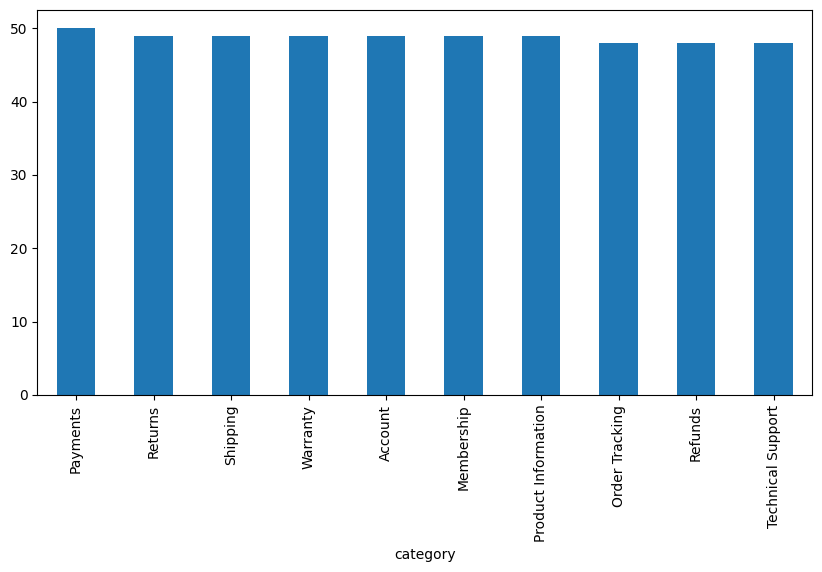

In [17]:
categories.plot.bar(figsize=(10,5))

## Save Documents

In [18]:
with open("../data/documents.pkl", "wb") as f:

    pickle.dump(documents, f)

print("Documents Saved Successfully")

Documents Saved Successfully


In [19]:
with open("../data/documents.pkl", "rb") as f:

    loaded_documents = pickle.load(f)

print("Loaded Documents:", len(loaded_documents))

Loaded Documents: 489


In [20]:
loaded_documents[5]

Document(metadata={'source': 'FAQ', 'category': 'Order Tracking'}, page_content='\nQuestion:\nHow do I track my shipment? (8)\n\nAnswer:\nOpen your order details to view the live shipment status.\n')